In [1]:
import numpy as np
from ofdm.metrics import calculate_cm
from ofdm.plots import plot_ccdf, plot_ccdf_compare
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from nnscf import NNSCFMapper, device, denormalize, criterion
import os

In [2]:
samples_per_L = 10000
data_size = 100
train_size = 70
val_size = 10
test_size = data_size - train_size - val_size
one_batch = None

if not test_size:
    one_batch = '00'

if one_batch:
    batch_idx = int(one_batch)
relev_dir = "./relev/"
norm_dir = "./norm/"

In [3]:
class OldOFDMDataset(Dataset, ):
    def __init__(self, pt_folder_path, part):
        self.folder_path = pt_folder_path
        self.part = part

    def __len__(self):
        return data_size # Assuming exactly data_size pre-computed .pt files, regardless of train/test split

    def __getitem__(self, idx):
        # Instantly loads the pre-normalized tensors directly into memory!
        file_path = os.path.join(self.folder_path, f"old_method_{idx:02d}_{self.part}.pt")
        # Load the dictionary
        data_pkg = torch.load(file_path, weights_only=False)

        # Return the tensors AND the scaling limits
        return (data_pkg['X_norm'], data_pkg['Y_norm'],
                data_pkg['X_min'], data_pkg['X_max'],
                data_pkg['Y_min'], data_pkg['Y_max'])

class NewOFDMDataset(Dataset):
    def __init__(self, pt_folder_path, part):
        self.folder_path = pt_folder_path
        self.part = part

    def __len__(self):
        return data_size # Assuming exactly data_size pre-computed .pt files, regardless of train/test split

    def __getitem__(self, idx):
        # Instantly loads the pre-normalized tensors directly into memory!
        file_path = os.path.join(self.folder_path, f"new_method_{idx:02d}_{self.part}.pt")
        # Load the dictionary
        data_pkg = torch.load(file_path, weights_only=False)

        # Return the tensors AND the scaling limits
        return (data_pkg['X_norm'], data_pkg['Y_norm'])

In [4]:
# Initialize DataLoaders with asynchronous loading (num_workers) and rapid memory transfer
dataset_real_old = OldOFDMDataset(norm_dir, part='real')
dataset_imag_old = OldOFDMDataset(norm_dir, part='imag')

if one_batch:
    # Use the one_batch file for testing
    test_dataset_real_old = Subset(dataset_real_old, range(batch_idx, batch_idx + 1))
    test_dataset_imag_old = Subset(dataset_imag_old, range(batch_idx, batch_idx + 1))
else:
    # Use the last test_size files for testing
    test_dataset_real_old = Subset(dataset_real_old, range(data_size - test_size, data_size))
    test_dataset_imag_old = Subset(dataset_imag_old, range(data_size - test_size, data_size))

# We set shuffle=False to ensure real and imag batches stay perfectly aligned
test_loader_real_old = DataLoader(test_dataset_real_old, batch_size=None, shuffle=False)
test_loader_imag_old = DataLoader(test_dataset_imag_old, batch_size=None, shuffle=False)


# Initialize DataLoaders with asynchronous loading (num_workers) and rapid memory transfer
dataset_real_new = NewOFDMDataset(norm_dir, part='real')
dataset_imag_new = NewOFDMDataset(norm_dir, part='imag')

if one_batch:
    # Use the one_batch file for testing
    test_dataset_real_new = Subset(dataset_real_new, range(batch_idx, batch_idx + 1))
    test_dataset_imag_new = Subset(dataset_imag_new, range(batch_idx, batch_idx + 1))
else:
    # Use the last test_size files for testing
    test_dataset_real_new = Subset(dataset_real_new, range(data_size - test_size, data_size))
    test_dataset_imag_new = Subset(dataset_imag_new, range(data_size - test_size, data_size))

# We set shuffle=False to ensure real and imag batches stay perfectly aligned
test_loader_real_new = DataLoader(test_dataset_real_new, batch_size=None, shuffle=False)
test_loader_imag_new = DataLoader(test_dataset_imag_new, batch_size=None, shuffle=False)

In [5]:
# 1. Load the Saved Models
Old_Mod_Re = NNSCFMapper().to(device)
Old_Mod_Im = NNSCFMapper().to(device)

Old_Mod_Re.load_state_dict(torch.load(os.path.join(relev_dir, f"old_method_weights_re.pth"), weights_only=True))
Old_Mod_Im.load_state_dict(torch.load(os.path.join(relev_dir, f"old_method_weights_im.pth"), weights_only=True))

Old_Mod_Re.eval()
Old_Mod_Im.eval()

# ! this part is actually unnecessary in the notebook as the checkpoints are already loaded
checkpoint_re = torch.load(
    os.path.join(relev_dir, f"new_method_weights_limits_re.pth"),
    weights_only=False
)
checkpoint_im = torch.load(
    os.path.join(relev_dir, f"new_method_weights_limits_im.pth"),
    weights_only=False
)

# 1. Load the Saved Models
New_Mod_Re = NNSCFMapper().to(device)
New_Mod_Im = NNSCFMapper().to(device)

New_Mod_Re.load_state_dict(checkpoint_re['model_state_dict'])
New_Mod_Im.load_state_dict(checkpoint_im['model_state_dict'])

New_Mod_Re.eval()
New_Mod_Im.eval()

# 2. Grab the saved normalization limits
# X_r_min = checkpoint_re['X_min']
# X_r_max = checkpoint_re['X_max']
Y_r_min = checkpoint_re['Y_min']
Y_r_max = checkpoint_re['Y_max']

# X_i_min = checkpoint_im['X_min']
# X_i_max = checkpoint_im['X_max']
Y_i_min = checkpoint_im['Y_min']
Y_i_max = checkpoint_im['Y_max']

In [6]:
# fixme: make sure this block denormalizes original and clipped values correctly

# Generate Predictions for all test_size test files
all_original_old, all_clipped_old, all_predicted_old = [], [], []

test_loss_real = 0.0
test_loss_imag = 0.0
with torch.no_grad():
    for (X_real, Y_real, X_r_min, X_r_max, _, _), (X_imag, Y_imag, X_i_min, X_i_max, _, _) in zip(test_loader_real_old, test_loader_imag_old):
        # Move inputs to device
        X_real, X_imag = X_real.to(device), X_imag.to(device)

        # 1. Flatten for memoryless prediction
        X_real_flat = X_real.view(-1, 1)
        X_imag_flat = X_imag.view(-1, 1)

        # Predict
        # ! shouldnt use .numpy() method because of criterion
        pred_real_flat = Old_Mod_Re(X_real_flat)
        pred_imag_flat = Old_Mod_Im(X_imag_flat)

        # 2. Calculate MSE Loss on the flat tensors
        loss_real = criterion(pred_real_flat, Y_real.view(-1, 1))
        loss_imag = criterion(pred_imag_flat, Y_imag.view(-1, 1))

        test_loss_real += loss_real.item()
        test_loss_imag += loss_imag.item()

        # 3. Reshape back to the original array shape (e.g. [10000, 1024])
        pred_real = pred_real_flat.view_as(X_real).cpu().numpy()
        pred_imag = pred_imag_flat.view_as(X_imag).cpu().numpy()

        # 4. Denormalize using the exact physical limits from the dictionary!
        # fixme: this should be Y, not X
        pred_denorm_real = denormalize(pred_real, (X_r_min, X_r_max))
        pred_denorm_imag = denormalize(pred_imag, (X_i_min, X_i_max))

        # 5. Reconstruct complex signals
        orig_complex = X_real.cpu().numpy() + 1j * X_imag.cpu().numpy()
        # fixme: should denormalize Y first
        clip_complex = Y_real.cpu().numpy() + 1j * Y_imag.cpu().numpy()
        pred_complex = pred_denorm_real + 1j * pred_denorm_imag

        all_original_old.append(orig_complex)
        all_clipped_old.append(clip_complex)
        all_predicted_old.append(pred_complex)

# Print the final average test metrics
avg_test_loss_real = test_loss_real / len(test_loader_real_old)
avg_test_loss_imag = test_loss_imag / len(test_loader_imag_old)

print(f'\n--- Test Set Metrics ({str(test_size) + "Unseen Files" if not one_batch else "1 Unseen File"}) ---')
print(f'Average Real Module MSE Loss: {avg_test_loss_real:.6f}')
print(f'Average Imag Module MSE Loss: {avg_test_loss_imag:.6f}')

# 4. Concatenate the test_size batches into one massive array for evaluation
original_complex_old = np.concatenate(all_original_old, axis=0)
clipped_complex_old = np.concatenate(all_clipped_old, axis=0)
predicted_complex_old = np.concatenate(all_predicted_old, axis=0)

print(f'Testing complete! Aggregated {test_size * samples_per_L if not one_batch else samples_per_L} OFDM symbols.')


--- Test Set Metrics (20Unseen Files) ---
Average Real Module MSE Loss: 0.000311
Average Imag Module MSE Loss: 0.092506
Testing complete! Aggregated 200000 OFDM symbols.


In [7]:
# fixme: make sure this block denormalizes original and clipped values correctly

# Generate Predictions for all test_size test files
all_original_new, all_clipped_new, all_predicted_new = [], [], []

test_loss_real = 0.0
test_loss_imag = 0.0
with torch.no_grad():
    for (X_real, Y_real), (X_imag, Y_imag) in zip(test_loader_real_new, test_loader_imag_new):
        # Move inputs to device
        X_real, X_imag = X_real.to(device), X_imag.to(device)

        # 1. Flatten for memoryless prediction
        X_real_flat = X_real.view(-1, 1)
        X_imag_flat = X_imag.view(-1, 1)

        # Predict
        # ! shouldnt use .numpy() method because of criterion
        pred_real_flat = New_Mod_Re(X_real_flat)
        pred_imag_flat = New_Mod_Im(X_imag_flat)

        # 2. Calculate MSE Loss on the flat tensors
        loss_real = criterion(pred_real_flat, Y_real.view(-1, 1))
        loss_imag = criterion(pred_imag_flat, Y_imag.view(-1, 1))

        test_loss_real += loss_real.item()
        test_loss_imag += loss_imag.item()

        # 3. Reshape back to the original array shape (e.g. [10000, 1024])
        pred_real = pred_real_flat.view_as(X_real).cpu().numpy()
        pred_imag = pred_imag_flat.view_as(X_imag).cpu().numpy()

        # 4. Denormalize using the exact physical limits from the dictionary!
        pred_denorm_real = denormalize(pred_real, (Y_r_min, Y_r_max))
        pred_denorm_imag = denormalize(pred_imag, (Y_i_min, Y_i_max))

        # 5. Reconstruct complex signals
        orig_complex = X_real.cpu().numpy() + 1j * X_imag.cpu().numpy()
        # fixme: should denormalize Y first
        clip_complex = Y_real.cpu().numpy() + 1j * Y_imag.cpu().numpy()
        pred_complex = pred_denorm_real + 1j * pred_denorm_imag

        all_original_new.append(orig_complex)
        all_clipped_new.append(clip_complex)
        all_predicted_new.append(pred_complex)

# Print the final average test metrics
avg_test_loss_real = test_loss_real / len(test_loader_real_new)
avg_test_loss_imag = test_loss_imag / len(test_loader_imag_new)

print(f'\n--- Test Set Metrics ({str(test_size) + "Unseen Files" if not one_batch else "1 Unseen File"}) ---')
print(f'Average Real Module MSE Loss: {avg_test_loss_real:.6f}')
print(f'Average Imag Module MSE Loss: {avg_test_loss_imag:.6f}')

# 4. Concatenate the test_size batches into one massive array for evaluation
original_complex_new = np.concatenate(all_original_new, axis=0)
clipped_complex_new = np.concatenate(all_clipped_new, axis=0)
predicted_complex_new = np.concatenate(all_predicted_new, axis=0)

print(f'Testing complete! Aggregated {test_size * samples_per_L if not one_batch else samples_per_L} OFDM symbols.')


--- Test Set Metrics (20Unseen Files) ---
Average Real Module MSE Loss: 0.000307
Average Imag Module MSE Loss: 0.027717
Testing complete! Aggregated 200000 OFDM symbols.


In [8]:
# 5. Calculate PAPR and CM for CCDF
orig_cm_old, clip_cm_old, pred_cm_old = [], [], []
orig_cm_new, clip_cm_new, pred_cm_new = [], [], []

# Iterate through the arrays
for i in range(test_size * samples_per_L if not one_batch else samples_per_L):
    orig_cm_old.append(calculate_cm(original_complex_old[i]))
    clip_cm_old.append(calculate_cm(clipped_complex_old[i]))
    pred_cm_old.append(calculate_cm(predicted_complex_old[i]))
    orig_cm_new.append(calculate_cm(original_complex_new[i]))
    clip_cm_new.append(calculate_cm(clipped_complex_new[i]))
    pred_cm_new.append(calculate_cm(predicted_complex_new[i]))

orig_cm_old, clip_cm_old, pred_cm_old = np.array(orig_cm_old), np.array(clip_cm_old), np.array(pred_cm_old)
orig_cm_new, clip_cm_new, pred_cm_new = np.array(orig_cm_new), np.array(clip_cm_new), np.array(pred_cm_new)

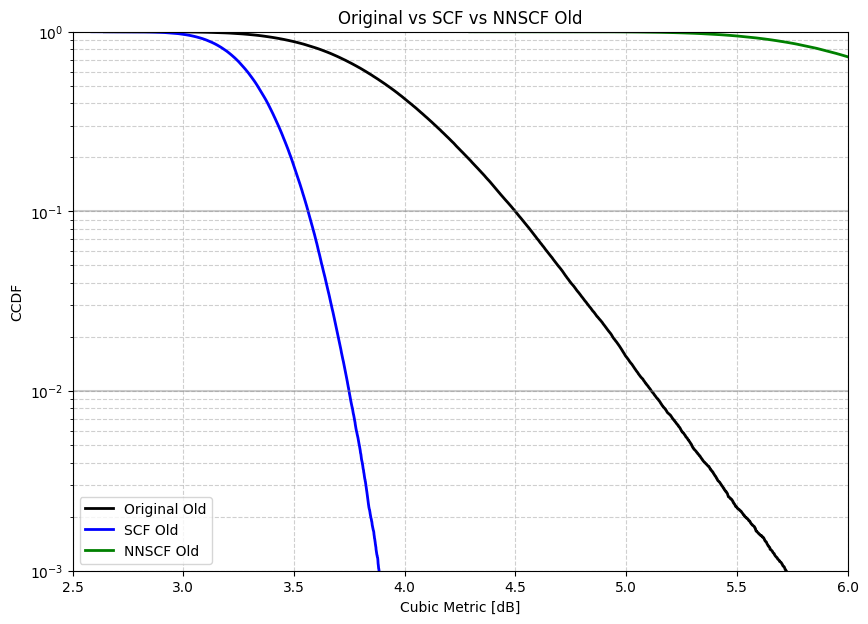

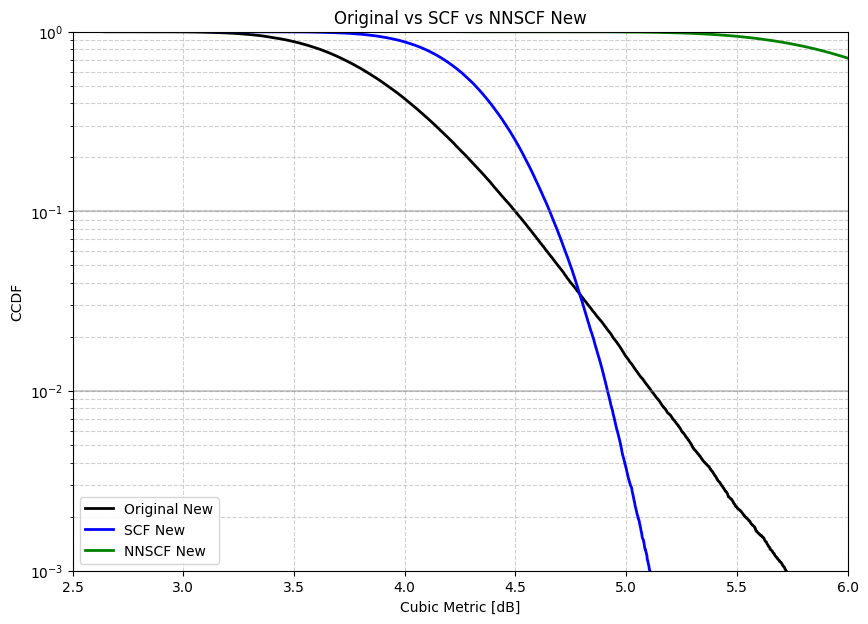

In [9]:
# 6. Plot the CCDF
labels_old = ['Original Old', f'SCF Old', f'NNSCF Old']
labels_new = ['Original New', f'SCF New', f'NNSCF New']
cm_list_old = [orig_cm_old, clip_cm_old, pred_cm_old]
cm_list_new = [orig_cm_new, clip_cm_new, pred_cm_new]

# fixme: both percentile and max are not the most efficient solutions

# todo: find a way to embed the floor part into the plotting function
# 1. Define the target y-levels (probabilities)
cm_target_y = 1e-3

# 2. Convert CCDF y-level to a standard percentile (e.g., 1e-4 becomes 99.99)
cm_percentile = (1.0 - cm_target_y) * 100.0

cm_vlines_old = [
    np.percentile(orig_cm_old, cm_percentile),
    np.percentile(clip_cm_old, cm_percentile),
    np.percentile(pred_cm_old, cm_percentile)
]
cm_vlines_new = [
    np.percentile(orig_cm_new, cm_percentile),
    np.percentile(clip_cm_new, cm_percentile),
    np.percentile(pred_cm_new, cm_percentile)
]

# 4. Plot!
cm_image_path_old = os.path.join(relev_dir, f"old_method_cm")
plot_ccdf_compare(cm_list_old, f'Original vs SCF vs NNSCF Old', labels_old, metric="CM", save=(cm_image_path_old + "_compare.png"))
# plot_ccdf(pred_cm_old, metric="cm", vlines=cm_vlines_old, save=(cm_image_path_old + ".png"))
cm_image_path_new = os.path.join(relev_dir, f"new_method_cm")
plot_ccdf_compare(cm_list_new, f'Original vs SCF vs NNSCF New', labels_new, metric="CM", save=(cm_image_path_new + "_compare.png"))
# plot_ccdf(pred_cm_new, metric="cm", vlines=cm_vlines_new, save=(cm_image_path_new + ".png"))